In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import EarlyStoppingCallback

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

# -----------------------
# A) Load your JSONL file
# -----------------------
# This reads each JSON line as one training example.
data_files = {
    "train": "/content/drive/MyDrive/nlpPro/data3/HebNLI_train.full.clean.jsonl",
    "validation": "/content/drive/MyDrive/nlpPro/data3/HebNLI_val.full.clean.jsonl",
    "test": "/content/drive/MyDrive/nlpPro/data3/HebNLI_test.full.clean.jsonl"
    }
ds = load_dataset("json", data_files=data_files)


# -----------------------
# B) Label mapping
# -----------------------
label_list = ["entailment", "contradiction", "neutral"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

def add_label_id(example):
    example["label"] = label2id[example["original_label"]]
    return example

ds = ds.map(add_label_id)

# -----------------------
# C) Tokenizer
# -----------------------
# Tokenizer turns Hebrew text into numbers the model understands.
model_name = "dicta-il/dictabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# -----------------------
# D) Model for 3-class classification - MOVED HERE
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Ensure PAD exists (some checkpoints are missing it)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# If tokenizer has more tokens than model embeddings, resize
if len(tokenizer) != model.config.vocab_size:
    model.resize_token_embeddings(len(tokenizer))

print("AFTER FIX -> model vocab_size:", model.config.vocab_size, "tokenizer len:", len(tokenizer))
print("pad token:", tokenizer.pad_token, "pad_id:", tokenizer.pad_token_id)


def tokenize_pair(example):
    return tokenizer(
        example["translation1"],
        example["translation2"],
        truncation=True,
        max_length=256,
    )

ds_tok = ds.map(tokenize_pair, batched=False)
cols = ["input_ids", "attention_mask", "label"]
ds_tok = ds_tok.remove_columns([c for c in ds_tok["train"].column_names if c not in cols])

def find_bad_example(split="train", limit=10000):
    emb_size = model.get_input_embeddings().weight.shape[0]
    ds_split = ds_tok[split]
    n = min(limit, len(ds_split))

    for i in range(n):
        ids = ds_split[i]["input_ids"]
        mx = max(ids)
        mn = min(ids)
        if mn < 0 or mx >= emb_size:
            print("BAD EXAMPLE FOUND!")
            print("split:", split, "index:", i)
            print("min_id:", mn, "max_id:", mx, "emb_size:", emb_size)
            print("translation1:", ds[split][i]["translation1"])
            print("translation2:", ds[split][i]["translation2"])
            print("input_ids:", ids[:80], "...")
            return i

    print(f"No bad examples found in first {n} rows of {split}")
    return None

find_bad_example("train")
find_bad_example("validation")
find_bad_example("test")


# This pads batches nicely (so all examples in a batch have same length).
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# -----------------------
# E) Metrics (what “results” you’ll see)
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# -----------------------
# F) Training settings
# -----------------------
args = TrainingArguments(
    output_dir="dictabert_final_fulltrain",
    learning_rate=4.177040568759707e-05,
    warmup_ratio=0.07339576952648837,
    weight_decay=0.036956832426279354,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
)


# -----------------------
# G) Trainer (does the training loop)
# -----------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.02)]
)

# -----------------------
# H) Train + Evaluate
# -----------------------
trainer.train()

print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_labels = test_out.label_ids
test_preds = np.argmax(test_logits, axis=-1)

print(classification_report(test_labels, test_preds, target_names=label_list, digits=4))
print("Confusion matrix (rows=true, cols=pred) label order:", label_list)
print(confusion_matrix(test_labels, test_preds))

# -----------------------
# I) Per-genre results (nice for your report)
# -----------------------
test_genres = ds["test"]["genre"]
print("\nPer-genre macro-F1:")
for g in sorted(set(test_genres)):
    idx = [i for i, gg in enumerate(test_genres) if gg == g]
    g_labels = test_labels[idx]
    g_preds = test_preds[idx]
    g_f1 = f1_score(g_labels, g_preds, average="macro")
    print(f"  {g:12s} n={len(idx):4d} macro_f1={g_f1:.4f}")

# -----------------------
# J) Save the model (required deliverable)
# -----------------------
trainer.save_model("/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping")
tokenizer.save_pretrained("/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping")
print('saving the modal!')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/299728 [00:00<?, ? examples/s]

Map:   0%|          | 0/1999 [00:00<?, ? examples/s]

...

No bad examples found in first 10000 rows of train
No bad examples found in first 1999 rows of validation
No bad examples found in first 884 rows of test


/tmp/ipython-input-1917476417.py:145: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 3}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.594700,0.572174,0.767384,0.766664
2,0.510700,0.569817,0.781891,0.781936
3,0.385500,0.580123,0.801401,0.801833



FINAL TEST RESULTS:


               precision    recall  f1-score   support

   entailment     0.8376    0.8651    0.8511       304
contradiction     0.8703    0.8306    0.8500       307
      neutral     0.7906    0.8022    0.7964       273

     accuracy                         0.8337       884
    macro avg     0.8328    0.8326    0.8325       884
 weighted avg     0.8344    0.8337    0.8338       884

Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[263  14  27]
 [ 21 255  31]
 [ 30  24 219]]

Per-genre macro-F1:
  fiction      n= 223 macro_f1=0.8828
  government   n= 206 macro_f1=0.8637
  letters      n=   7 macro_f1=0.8222
  nineeleven   n=   6 macro_f1=0.8222
  oup          n=   4 macro_f1=1.0000
  slate        n= 215 macro_f1=0.7846
  travel       n= 223 macro_f1=0.7931
saving the modal!


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# One-vs-Rest ROC AUC
auc_macro_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="weighted")

print("ROC-AUC macro (OvR):", auc_macro_ovr)
print("ROC-AUC weighted (OvR):", auc_weighted_ovr)


ROC-AUC macro (OvR): 0.9447815005235016
ROC-AUC weighted (OvR): 0.9451973001491286


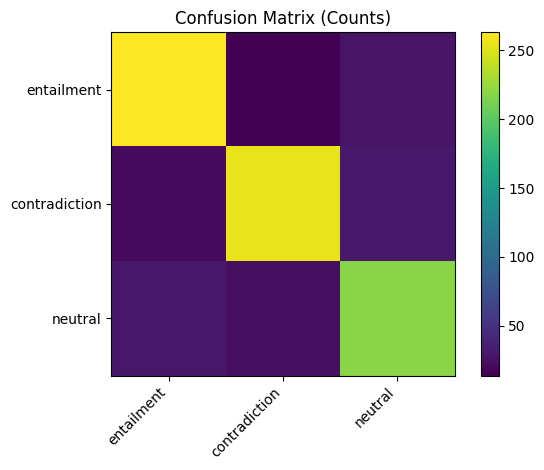

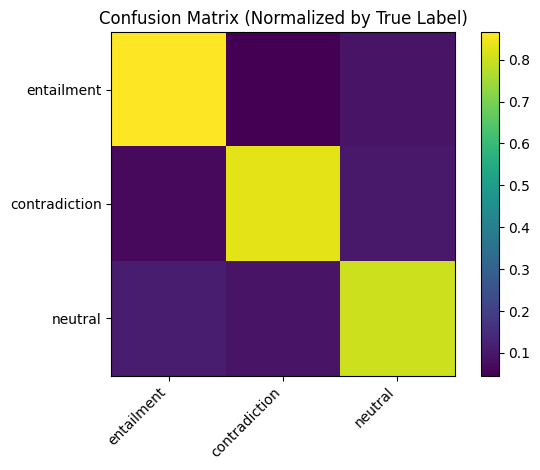

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)

# counts
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Counts)")
plt.xticks(range(len(label_list)), label_list, rotation=45, ha="right")
plt.yticks(range(len(label_list)), label_list)
plt.colorbar()
plt.tight_layout()
plt.show()

# normalized by true class
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure()
plt.imshow(cm_norm)
plt.title("Confusion Matrix (Normalized by True Label)")
plt.xticks(range(len(label_list)), label_list, rotation=45, ha="right")
plt.yticks(range(len(label_list)), label_list)
plt.colorbar()
plt.tight_layout()
plt.show()


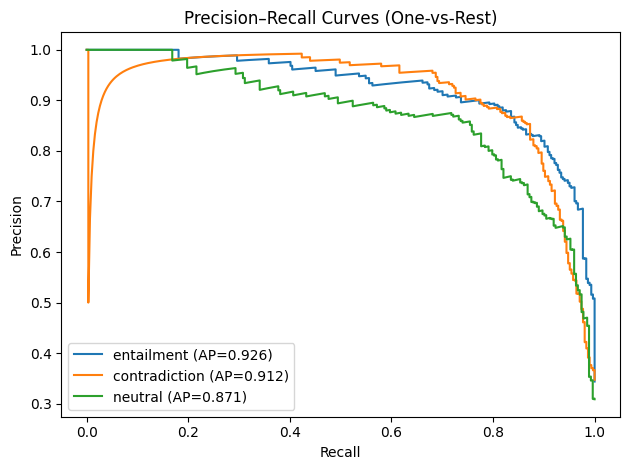

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true_bin = label_binarize(test_labels, classes=[0,1,2])  # shape (N,3)

plt.figure()
for i, name in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

inv_id2label = {0:"entailment", 1:"contradiction", 2:"neutral"}

rows = []
for i in range(len(test_labels)):
    true_id = int(test_labels[i])
    pred_id = int(test_preds[i])
    if true_id != pred_id:
        rows.append({
            "i": i,
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": inv_id2label[true_id],
            "pred": inv_id2label[pred_id],
            "pred_conf": float(probs[i, pred_id]),
            "true_conf": float(probs[i, true_id]),
            "margin": float(probs[i, pred_id] - probs[i, true_id]),
        })

err_df = pd.DataFrame(rows)
print("Total errors:", len(err_df))
err_df.sort_values("pred_conf", ascending=False).head(10)




Total errors: 147


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
103,628,fiction,קאדאן המשיך.,קאדאן סירב להפסיק.,neutral,contradiction,0.992509,0.004458,0.988051
84,509,travel,"מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.","במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה.",contradiction,neutral,0.988688,0.007083,0.981605
102,619,government,"זה היה דומה למן מגן עדן - אלפי דולרים שירדו, ל...",חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול א...,contradiction,neutral,0.988540,0.007785,0.980754
138,809,slate,"כל הכבוד לקירסטי אלי, שמגלמת עכשיו דוגמנית לשע...","קירסטי אלי מגלמת דוגמנית לשעבר, כיום מבוגרת, ב...",entailment,neutral,0.987927,0.007720,0.980207
114,679,slate,רק תחושת בטן.,זה סתם ניחוש.,entailment,contradiction,0.987156,0.008636,0.978520
41,253,slate,"הברברים, בקיצור, נמצאים בשער - וקושרים קשר נגדנו.","הברברים חוסמים את השער, מונעים את בריחתנו ומתכ...",neutral,contradiction,0.986160,0.011491,0.974670
127,754,fiction,הוא התנשף באוויר וראשו הלם.,הראש שלו כאב נורא.,entailment,neutral,0.985686,0.008066,0.977621
28,188,slate,אני יודע על מה אני מדבר למרות שאני עלול להשתכר...,"כשאני משתכר ומתנהג בילדותיות, אני רץ בלי בגדים.",contradiction,neutral,0.984727,0.012370,0.972357
21,160,slate,"הם אולי טוענים זאת, אבל הופעתם בצעיפים האלה מב...",הטענה שלהם נכונה.,contradiction,neutral,0.984577,0.006663,0.977914
86,517,travel,לאלה שעדיין נותרה להם מעט אנרגיה לאחר ליל הולל...,אתם יכולים להצטרף לתחרות הטריאתלון בחג המולד.,contradiction,neutral,0.982371,0.014326,0.968045


In [ ]:
print("Total errors:", len(err_df))
err_df.head(3)


Total errors: 147


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
0,5,fiction,"היא תתאים לו יפה מאוד, אמר טומי בהתנשאות.","היא מתאימה לו באופן מושלם, אמר טומי בקרירות",neutral,entailment,0.924018,0.057254,0.866764
1,14,fiction,"אלמלא שני דברים, ייתכן שחלמתי את כל העניין",לא ידעתי אם זה אמיתי או בדיוני.,contradiction,entailment,0.533615,0.071671,0.461944
2,17,fiction,"אם הם יבואו, הם ייחתכו לחתיכות,"" אמר אודן.",אודן היה בטוח שנביס אותם אם הם יתקרבו אלינו.,neutral,entailment,0.642295,0.273287,0.369008


In [ ]:
print("\nTop 5 confidently wrong:")
display(err_df.sort_values("pred_conf", ascending=False).head(5))

print("\nTop 5 ambiguous (small margin):")
display(err_df.sort_values("margin", ascending=True).head(5))

print("\nErrors by genre:")
display(err_df["genre"].value_counts())



Top 5 confidently wrong:


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
103,628,fiction,קאדאן המשיך.,קאדאן סירב להפסיק.,neutral,contradiction,0.992509,0.004458,0.988051
84,509,travel,"מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.","במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה.",contradiction,neutral,0.988688,0.007083,0.981605
102,619,government,"זה היה דומה למן מגן עדן - אלפי דולרים שירדו, ל...",חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול א...,contradiction,neutral,0.988540,0.007785,0.980754
138,809,slate,"כל הכבוד לקירסטי אלי, שמגלמת עכשיו דוגמנית לשע...","קירסטי אלי מגלמת דוגמנית לשעבר, כיום מבוגרת, ב...",entailment,neutral,0.987927,0.007720,0.980207
114,679,slate,רק תחושת בטן.,זה סתם ניחוש.,entailment,contradiction,0.987156,0.008636,0.978520



Top 5 ambiguous (small margin):


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
141,820,travel,ניתן לחקור את הטריטוריות החדשות על ידי נסיעה ב...,רכבת קאולון קנטון עוצרת ביותר מחמש תחנות בין ה...,entailment,contradiction,0.374589,0.369065,0.005524
75,471,travel,"סניף זה של המוזיאון הלאומי של אירלנד, שנפתח בש...",הסניף עצמו נפתח ב-1997.,entailment,neutral,0.481528,0.468253,0.013275
42,265,slate,כמה אנליסטים טענו שהמחקר תומך בשני דברים חשובי...,"הדנ""א של האדם שונה באופן דרסטי בין גזעים.",contradiction,neutral,0.373552,0.355798,0.017753
59,389,government,צמיחה כלכלית גדולה יותר שנובעת מחיסכון גדול יו...,חיסכון בכסף מוקדם יותר בקריירה שלהם יעזור גם ל...,entailment,neutral,0.504716,0.475628,0.029088
125,752,fiction,"הוא שכר חדר, וגם אני שכרתי אחד.","הוא שכר חדר, אבל לא היה לי מספיק כסף בשביל לשכ...",contradiction,neutral,0.516591,0.474227,0.042364



Errors by genre:


,count
genre,
slate,46
travel,46
government,28
fiction,25
letters,1
nineeleven,1


In [ ]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוהב לאכול כל היום"
hypothesis = "אני אוהב לאכול רק עכשיו"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

The tokenizer you are loading from '/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.8715


In [ ]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני הואב לאכול כל היום"
hypothesis = "אני אוהב לאכול רק עכשיו"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

The tokenizer you are loading from '/content/drive/MyDrive/nlpPro/dictabert_nli_full_best_early_stopping' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.4879


In [ ]:
# finding fp/fn per label
import numpy as np

labels = ["entailment","contradiction","neutral"]
for i, name in enumerate(labels):
    fp = np.sum((test_preds == i) & (test_labels != i))
    fn = np.sum((test_preds != i) & (test_labels == i))
    tp = np.sum((test_preds == i) & (test_labels == i))
    tn = np.sum((test_preds != i) & (test_labels != i))
    print(f"{name:13s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")


entailment    TP=263 FP= 51 FN= 41 TN=529
contradiction TP=255 FP= 38 FN= 52 TN=539
neutral       TP=219 FP= 58 FN= 54 TN=553


In [ ]:
# examples for FP/FN of neutral
target = "neutral"
target_id = labels.index(target)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]

print("FP examples for", target, ":", len(fp_idx))
print("FN examples for", target, ":", len(fn_idx))

# show a few
for i in fp_idx[:5]:
    print("\nTRUE:", labels[test_labels[i]], "| PRED:", labels[test_preds[i]], "| genre:", ds["test"][int(i)]["genre"])
    print("t1:", ds["test"][int(i)]["translation1"])
    print("t2:", ds["test"][int(i)]["translation2"])

FP examples for neutral : 58
FN examples for neutral : 54

TRUE: entailment | PRED: neutral | genre: fiction
t1: להתראות, ובהצלחה.
t2: אני מאחל לך את כל ההצלחה שבעולם כשאתה עוזב.

TRUE: entailment | PRED: neutral | genre: fiction
t1: ובפעם המאה, אני אגיד לך שאתה כאן.
t2: אני אומר לך איפה אתה נמצא, כפי שכבר עשיתי פעמים רבות.

TRUE: contradiction | PRED: neutral | genre: fiction
t1: ספר אלקטרוני חינם מ- ://./
t2: הספר הוא בכריכה רכה.

TRUE: entailment | PRED: neutral | genre: fiction
t1: ברור שהתמונה בתעודת הזהות לא תתאים יותר לפנים שלי, אבל זה יספיק כדי לעבור את האבטחה האלקטרונית.
t2: הפנים שלי השתנו.

TRUE: entailment | PRED: neutral | genre: fiction
t1: גבר הציץ מהחלון, בדיוק כשהם התחילו.
t2: אדם ראה אותם דרך החלון מיד


In [ ]:
import numpy as np
from scipy.special import softmax
import pickle

# test_logits from trainer.predict(...)
probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# Prepare data for saving
data_to_save = {
    'err_df': err_df,
    'test_labels': test_labels,
    'test_preds': test_preds,
    'probs': probs
}

# Define the path to save in Google Drive
save_path = '/content/drive/MyDrive/nlpPro/dicta_nli_analysis_data.pkl'

# Save the data using pickle
with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f'All relevant analysis data saved to {save_path}')

All relevant analysis data saved to /content/drive/MyDrive/nlpPro/dicta_nli_analysis_data.pkl


In [ ]:
target = "neutral"
target_id = labels.index(target)

pred_neutral_idx = np.where(test_preds == target_id)[0]
avg_conf_pred_neutral = probs[pred_neutral_idx, target_id].mean()
print("Avg confidence when predicting neutral:", avg_conf_pred_neutral)

true_neutral_idx = np.where(test_labels == target_id)[0]
avg_conf_true_neutral = probs[true_neutral_idx, target_id].mean()
print("Avg confidence on TRUE neutral examples:", avg_conf_true_neutral)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]
avg_conf_fp = probs[fp_idx, target_id].mean() if len(fp_idx) else float("nan")
avg_conf_fn = probs[fn_idx, target_id].mean() if len(fn_idx) else float("nan")
print("Avg P(neutral) for FP neutral:", avg_conf_fp)
print("Avg P(neutral) for FN neutral:", avg_conf_fn)

avg_wrong_conf_fn = probs[fn_idx, test_preds[fn_idx]].mean() if len(fn_idx) else float("nan")
print("Avg confidence in the WRONG predicted label (on FN neutral):", avg_wrong_conf_fn)



Avg confidence when predicting neutral: 0.895486
Avg confidence on TRUE neutral examples: 0.7733882
Avg P(neutral) for FP neutral: 0.7775431
Avg P(neutral) for FN neutral: 0.15153438
Avg confidence in the WRONG predicted label (on FN neutral): 0.8034236


In [ ]:
import pandas as pd
import numpy as np
from scipy.special import softmax

probs = softmax(test_logits, axis=1)

err_rows = []
for i in range(len(test_labels)):
    t = int(test_labels[i]); p = int(test_preds[i])
    if t != p:
        err_rows.append({
            "i": i,
            "pairID": ds["test"][i].get("pairID", None),
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": labels[t],
            "pred": labels[p],
            "pred_conf": float(probs[i, p]),
            "true_prob": float(probs[i, t]),
            "margin": float(probs[i, p] - probs[i, t]),
        })

err_df = pd.DataFrame(err_rows)
print("Total errors:", len(err_df))
err_df.sort_values("pred_conf", ascending=False).head(10)


Total errors: 147


,i,pairID,genre,t1,t2,true,pred,pred_conf,true_prob,margin
103,628,140273n,fiction,קאדאן המשיך.,קאדאן סירב להפסיק.,neutral,contradiction,0.992509,0.004458,0.988051
84,509,43241c,travel,"מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.","במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה.",contradiction,neutral,0.988688,0.007083,0.981605
102,619,24875c,government,"זה היה דומה למן מגן עדן - אלפי דולרים שירדו, ל...",חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול א...,contradiction,neutral,0.988540,0.007785,0.980754
138,809,144779e,slate,"כל הכבוד לקירסטי אלי, שמגלמת עכשיו דוגמנית לשע...","קירסטי אלי מגלמת דוגמנית לשעבר, כיום מבוגרת, ב...",entailment,neutral,0.987927,0.007720,0.980207
114,679,65249e,slate,רק תחושת בטן.,זה סתם ניחוש.,entailment,contradiction,0.987156,0.008636,0.978520
41,253,109011n,slate,"הברברים, בקיצור, נמצאים בשער - וקושרים קשר נגדנו.","הברברים חוסמים את השער, מונעים את בריחתנו ומתכ...",neutral,contradiction,0.986160,0.011491,0.974670
127,754,56595e,fiction,הוא התנשף באוויר וראשו הלם.,הראש שלו כאב נורא.,entailment,neutral,0.985686,0.008066,0.977621
28,188,123430c,slate,אני יודע על מה אני מדבר למרות שאני עלול להשתכר...,"כשאני משתכר ומתנהג בילדותיות, אני רץ בלי בגדים.",contradiction,neutral,0.984727,0.012370,0.972357
21,160,25192c,slate,"הם אולי טוענים זאת, אבל הופעתם בצעיפים האלה מב...",הטענה שלהם נכונה.,contradiction,neutral,0.984577,0.006663,0.977914
86,517,8477c,travel,לאלה שעדיין נותרה להם מעט אנרגיה לאחר ליל הולל...,אתם יכולים להצטרף לתחרות הטריאתלון בחג המולד.,contradiction,neutral,0.982371,0.014326,0.968045


In [ ]:
# option 1
import numpy as np
import pandas as pd
from scipy.special import softmax

label_list = ["entailment", "contradiction", "neutral"]
id2label = {i:l for i,l in enumerate(label_list)}

# test_logits, test_labels, test_preds must already exist
probs = softmax(test_logits, axis=1)  # shape (N, 3)


In [ ]:
# option 1 to check if negative like no in one t1 and not the other is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues ? no just 6
import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")

def has_neg(s):
    return bool(NEG_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)



How many of top 30 errors have negation flip: 4


,true,pred,pred_conf,t1,t2
28,contradiction,neutral,0.984727,אני יודע על מה אני מדבר למרות שאני עלול להשתכר...,"כשאני משתכר ומתנהג בילדותיות, אני רץ בלי בגדים."
97,neutral,contradiction,0.979401,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק..."
62,contradiction,neutral,0.973463,זה מעביר את האחריות לבצע את ההתערבות לידי יחיד...,רופאים לעתים קרובות אוהבים לבצע התערבויות כי ה...
112,neutral,contradiction,0.970927,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...


In [ ]:
# option 1 to check if sentences include dates, the model may ignore them and this is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues ? no just 0
import re

TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def has_neg(s):
    return bool(TEMP_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)


How many of top 30 errors have negation flip: 0


,true,pred,pred_conf,t1,t2


In [ ]:
# option 1 to check if sentences include numbers, the model may ignore them and this is the coes of the the high conf
# just 7

NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")

def has_number(s):
    return bool(NUM_RE.search(str(s)))

top["has_num"] = top.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)
print("How many of top 30 errors have numbers:", top["has_num"].sum())
top[top["has_num"]][["true","pred","pred_conf","t1","t2"]].head(5)



How many of top 30 errors have numbers: 2


,true,pred,pred_conf,t1,t2
84,contradiction,neutral,0.988688,"מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.","במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה."
102,contradiction,neutral,0.988540,"זה היה דומה למן מגן עדן - אלפי דולרים שירדו, ל...",חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול א...


In [ ]:
# option 1
# In several cases the model predicts entailment even though sentence 2 adds details not stated in sentence 1.
# This suggests the model relies on common-sense assumptions rather than strict logical entailment.
# so we check if

guess_df = err_df[(err_df["true"]=="neutral") & (err_df["pred"]=="entailment")].copy()
guess_df = guess_df.sort_values("pred_conf", ascending=False).head(15)

print(f'amount of gussing: {len(guess_df)}')
for _, r in guess_df.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


amount of gussing: 15

TRUE=neutral PRED=entailment conf=0.981
t1: לבראון תומאס יש מחלקת פשתן נהדרת בקומה העליונה.
t2: לבראון תומאס יש מחלקה נהדרת לפשתן.

TRUE=neutral PRED=entailment conf=0.977
t1: אבל מה עם העורכים האחרים של הדיילי קאל, שלא יכלו לומר שהם סבלו בשם האמונות שלהם, בקמפוס שפעם נודע בשמאלנות שלו?
t2: כמה עורכים של הדיילי קאל ציינו שהקמפוס היה פעם שמאלני.

TRUE=neutral PRED=entailment conf=0.972
t1: בסדר, דוגמה גרועה.
t2: זו דוגמה רעה.

TRUE=neutral PRED=entailment conf=0.968
t1: עקוב אחר לוח הקנו המואר מעליך כדי לראות אם עולים לך מספיק מספרים כדי שתוכל לזכות.
t2: לוח הקנו נדלק ומראה לך אילו מספרים נבחרו.

TRUE=neutral PRED=entailment conf=0.957
t1: בגן החיות של אדינבורו יש מצעד פינגווינים כל יום במהלך הקיץ.
t2: כל מי שמבקר בקיץ בגן החיות של אדינבורו רואים את מצעדי הפינגווינים.

TRUE=neutral PRED=entailment conf=0.957
t1: נירינג אומר שזה בעיקר קודיפיקציה של החלטת בית המשפט העליון מ-1988, ולא היה שם הרבה יותר נטל על איגודים להוכיח שיש להם את רשות החברים להוציא כסף על מטרות פ

In [ ]:
# option 1
# Maybe the label is wrong
# 2 ways to ckeck this:
# number 1 if confidence > 0.95
noise_candidates = err_df[err_df["pred_conf"] > 0.95].sort_values("pred_conf", ascending=False).head(20)
print(f'amount of noise candidates: {len(noise_candidates)}')

for _, r in noise_candidates.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f} genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


amount of noise candidates: 20

TRUE=neutral PRED=contradiction conf=0.993 genre=fiction
t1: קאדאן המשיך.
t2: קאדאן סירב להפסיק.

TRUE=contradiction PRED=neutral conf=0.989 genre=travel
t1: מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.
t2: במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה.

TRUE=contradiction PRED=neutral conf=0.989 genre=government
t1: זה היה דומה למן מגן עדן - אלפי דולרים שירדו, לעתים קרובות באופן בלתי צפוי, לידיהם של חצי מיליון תושבי קנטאקי ואינדיאנה החודש.
t2: חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול אלפי דולרים מתושבי קנטקי.

TRUE=entailment PRED=neutral conf=0.988 genre=slate
t1: כל הכבוד לקירסטי אלי, שמגלמת עכשיו דוגמנית לשעבר, מזדקנת, שדגמנה בעבר הלבשה התחתונה. מטורפת פחות מלוסי, בוגרת יותר ממרי (ריצ'רד קורליס, מה-). טום שיילס מהוושינגטון פוסט חולק על כך, וקורא לאלי ״נוירוטית באופן קשה לצפייה, כמעט תמיד אחוזת טירוף קדחתני".
t2: קירסטי אלי מגלמת דוגמנית לשעבר, כיום מבוגרת, בתוכנית הטלוויזיה.

TRUE=entailment PRED=contradiction conf=0.987 genre=slate
t1: רק תחו

In [ ]:
# option 1
# the second way to check if the labes are wrong is by checkig if there is a overlap
# so the PRED label  should be 'entailment' but we get neutral / contradictions

def overlap_ratio(t1, t2):
    A = set(re.findall(r"[\u0590-\u05FF]{2,}", str(t1)))
    B = set(re.findall(r"[\u0590-\u05FF]{2,}", str(t2)))
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

err_df["overlap"] = err_df.apply(lambda r: overlap_ratio(r["t1"], r["t2"]), axis=1)

suspect_paraphrase = err_df[err_df["overlap"] > 0.45].sort_values("pred_conf", ascending=False).head(15)
print(f'amount of suspect paraphrase: {len(suspect_paraphrase)}')
suspect_paraphrase[["true","pred","pred_conf","overlap","t1","t2"]].head(5)


amount of suspect paraphrase: 3


,true,pred,pred_conf,overlap,t1,t2
40,neutral,entailment,0.914347,0.555556,בוב באר הוא אורוויל פאובוס של 1998.,בוב באר משחק תפקיד במחזה של אורוויל פאובוס
95,neutral,entailment,0.585677,0.500000,האדם הראשון שנוגע בקרקע עם חלק בגוף מלבד הרגלי...,האדם הראשון שנוגע עם הידיים בקרקע מפסיד.
54,contradiction,neutral,0.513975,0.466667,"רשיונות פס-רחב הוצעו למכרז עבור בלוקים , ו-. א...",רשיונות פס-רחב הוצעו בלעדית במכרז עבור בלוקים ...


In [ ]:
# option 2
# to check which confusion happens the most:
import pandas as pd

# err_df must have columns: true, pred, pred_conf, genre, t1, t2
mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(mistake_counts.to_string(index=False))


         true          pred  count
contradiction       neutral     31
      neutral    entailment     30
   entailment       neutral     27
      neutral contradiction     24
contradiction    entailment     21
   entailment contradiction     14


In [ ]:
# option 2
# to inspect this type of error because its the most times th model got confused

true_label = "entailment"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)

for _, r in subset.iterrows():
    print("\n" + "="*80)
    print(f"TRUE={r['true']} | PRED={r['pred']} | conf={r['pred_conf']:.3f} | genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


How many mistakes of this type: 27
Average confidence for this wrong prediction: 0.7457073606826641

TRUE=entailment | PRED=neutral | conf=0.988 | genre=slate
t1: כל הכבוד לקירסטי אלי, שמגלמת עכשיו דוגמנית לשעבר, מזדקנת, שדגמנה בעבר הלבשה התחתונה. מטורפת פחות מלוסי, בוגרת יותר ממרי (ריצ'רד קורליס, מה-). טום שיילס מהוושינגטון פוסט חולק על כך, וקורא לאלי ״נוירוטית באופן קשה לצפייה, כמעט תמיד אחוזת טירוף קדחתני".
t2: קירסטי אלי מגלמת דוגמנית לשעבר, כיום מבוגרת, בתוכנית הטלוויזיה.

TRUE=entailment | PRED=neutral | conf=0.986 | genre=fiction
t1: הוא התנשף באוויר וראשו הלם.
t2: הראש שלו כאב נורא.

TRUE=entailment | PRED=neutral | conf=0.982 | genre=travel
t1: מחרוזות של דגלי תפילה נמתחות מצריח הפעמון, וסביב הבסיס יש מאות גלגלי תפילה קטנים.
t2: דת היא דבר חשוב כאן.

TRUE=entailment | PRED=neutral | conf=0.979 | genre=slate
t1: זאת מחויבות לחינוך כללי - סדרה של קורסים שמטרתה לפתח חשיבה ביקורתית במגוון רחב של דיסציפלינות - וזאת בניגוד להתמחות מוקדמת.
t2: חינוך כללי מתמקד בפיתוח כישורי חשיבה ביק

In [ ]:
# option 2
# to inspect this type of error becaues its the scond most time the model got confused

true_label = "contradiction"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)

for _, r in subset.iterrows():
    print("\n" + "="*80)
    print(f"TRUE={r['true']} | PRED={r['pred']} | conf={r['pred_conf']:.3f} | genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


How many mistakes of this type: 31
Average confidence for this wrong prediction: 0.8052711429134491

TRUE=contradiction | PRED=neutral | conf=0.989 | genre=travel
t1: מ-1309 עד 1377, אביניון הייתה מושב האפיפיור.
t2: במהלך תקופה זו, כולם אישרו את העבודה שמנהיגם עשה.

TRUE=contradiction | PRED=neutral | conf=0.989 | genre=government
t1: זה היה דומה למן מגן עדן - אלפי דולרים שירדו, לעתים קרובות באופן בלתי צפוי, לידיהם של חצי מיליון תושבי קנטאקי ואינדיאנה החודש.
t2: חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול אלפי דולרים מתושבי קנטקי.

TRUE=contradiction | PRED=neutral | conf=0.985 | genre=slate
t1: אני יודע על מה אני מדבר למרות שאני עלול להשתכר ולהתנהג בילדותיות מבחינה חברתית ...
t2: כשאני משתכר ומתנהג בילדותיות, אני רץ בלי בגדים.

TRUE=contradiction | PRED=neutral | conf=0.985 | genre=slate
t1: הם אולי טוענים זאת, אבל הופעתם בצעיפים האלה מבטלת את הפרשנות הזאת.
t2: הטענה שלהם נכונה.

TRUE=contradiction | PRED=neutral | conf=0.982 | genre=travel
t1: לאלה שעדיין נותרה להם מעט אנרגיה לאחר ל

In [ ]:
# option 2
# Now we ask: why does neutral become contradiction?
# Common reasons: negation, strong words, numbers, time, etc.

import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def tags_for_pair(t1, t2):
    tags = []
    t1 = str(t1); t2 = str(t2)

    # negation in exactly one sentence
    if bool(NEG_RE.search(t1)) ^ bool(NEG_RE.search(t2)):
        tags.append("negation_flip")

    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("numbers")

    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("time")

    return tags

subset2 = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()
subset2["tags"] = subset2.apply(lambda r: tags_for_pair(r["t1"], r["t2"]), axis=1)

print("Tag counts inside this mistake type:")
print(subset2.explode("tags")["tags"].value_counts())


Tag counts inside this mistake type:
tags
numbers          8
negation_flip    7
time             2
Name: count, dtype: int64


In [ ]:
import re
import pandas as pd
import numpy as np

# err_df should already contain: t1,t2,true,pred,genre,pred_conf,margin
# If not, build it as we did earlier.

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|שנה|שנת|חודש|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")
NUM_RE  = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
PRON_RE = re.compile(r"\b(הוא|היא|הם|הן|אותו|אותה|להם|להן|שלו|שלה|שלהם|שלהן)\b")

def tokenize_set(s):
    # Hebrew-only “word” tokens
    return set(re.findall(r"[\u0590-\u05FF]{2,}", s))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def detect_patterns(t1, t2, pred_conf=None, margin=None):
    tags = []

    # Negation flip: negation present in exactly one of the sentences
    n1 = bool(NEG_RE.search(t1))
    n2 = bool(NEG_RE.search(t2))
    if n1 ^ n2:
        tags.append("Negation flip")

    # Temporal
    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("Temporal reasoning")

    # Numbers / quantifiers
    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("Quantifiers / numbers")

    # Coreference / pronouns
    if PRON_RE.search(t1) or PRON_RE.search(t2):
        tags.append("Coreference / pronouns")

    # Lexical overlap trap: lots of shared words (tends to confuse neutral vs entailment)
    A = tokenize_set(t1)
    B = tokenize_set(t2)
    overlap = jaccard(A, B)
    if overlap >= 0.35:   # tune threshold if needed
        tags.append("Lexical overlap trap")

    # Ambiguity: model not confident (or small margin)
    if pred_conf is not None and pred_conf < 0.45:
        tags.append("Ambiguity")
    if margin is not None and abs(margin) < 0.10:
        if "Ambiguity" not in tags:
            tags.append("Ambiguity")

    return tags

# Apply to err_df
err_df = err_df.copy()
err_df["tags"] = err_df.apply(
    lambda r: detect_patterns(r["t1"], r["t2"], r.get("pred_conf"), r.get("margin")),
    axis=1
)

# Explode into one tag per row for analysis
exploded = err_df.explode("tags")
tag_counts = exploded["tags"].value_counts(dropna=True)
print(tag_counts)


tags
Coreference / pronouns    62
Quantifiers / numbers     31
Negation flip             30
Temporal reasoning        11
Ambiguity                  9
Lexical overlap trap       7
Name: count, dtype: int64


In [ ]:
top_conf = err_df.sort_values("pred_conf", ascending=False).head(30)
top_conf[["genre","true","pred","pred_conf", "true_prob","margin"]].head(10)


,genre,true,pred,pred_conf,true_prob,margin
103,fiction,neutral,contradiction,0.992509,0.004458,0.988051
84,travel,contradiction,neutral,0.988688,0.007083,0.981605
102,government,contradiction,neutral,0.988540,0.007785,0.980754
138,slate,entailment,neutral,0.987927,0.007720,0.980207
114,slate,entailment,contradiction,0.987156,0.008636,0.978520
41,slate,neutral,contradiction,0.986160,0.011491,0.974670
127,fiction,entailment,neutral,0.985686,0.008066,0.977621
28,slate,contradiction,neutral,0.984727,0.012370,0.972357
21,slate,contradiction,neutral,0.984577,0.006663,0.977914
86,travel,contradiction,neutral,0.982371,0.014326,0.968045


In [ ]:
top_conf_exploded = top_conf.explode("tags")
print(top_conf_exploded["tags"].value_counts())


tags
Coreference / pronouns    11
Negation flip              4
Quantifiers / numbers      2
Lexical overlap trap       2
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:")
print(cm)

mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nMistake Counts (True vs. Predicted):")
print(mistake_counts.to_string(index=False))

Confusion Matrix:
[[263  14  27]
 [ 21 255  31]
 [ 30  24 219]]

Mistake Counts (True vs. Predicted):
         true          pred  count
contradiction       neutral     31
      neutral    entailment     30
   entailment       neutral     27
      neutral contradiction     24
contradiction    entailment     21
   entailment contradiction     14


In [ ]:
def slice_errors(true_label, pred_label):
    sub = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)]
    return sub.sort_values("pred_conf", ascending=False)

sub = slice_errors("neutral","contradiction")
print("count:", len(sub))
sub.head(5)[["genre","pred_conf","t1","t2"]]


count: 24


,genre,pred_conf,t1,t2
103,fiction,0.992509,קאדאן המשיך.,קאדאן סירב להפסיק.
41,slate,0.986160,"הברברים, בקיצור, נמצאים בשער - וקושרים קשר נגדנו.","הברברים חוסמים את השער, מונעים את בריחתנו ומתכ..."
97,travel,0.979401,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק..."
112,slate,0.970927,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...
4,fiction,0.928844,"אדרין המשיך במונולוג שלו, ותיאר את הרציחות המח...",הרוצחים לא נתפסו.
